#### Analysis Goal
Generating reliable production expectations and risk bands for investment planning by removing the 2015–2023 monthly and annual solar irradiance patterns from PVGIS data for Turkiye.

## Problem Definition (Business Understanding)

### Business Objective
The purpose of this project is to help energy companies and energy investors make faster, more accurate decisions in solar power plant (SPP) investments. Specifically, the goal is to provide data-driven prioritization for selecting investment provinces and regions across Turkiye.

### Who Will Use This Project?
- Energy companies (business development and project development teams)
- Energy investors
- Financial evaluation and feasibility teams

### Which Decision Will It Improve?
- Location selection for solar power plant investments
- Prioritization of candidate investment regions
- Early elimination of low-potential locations during the pre-feasibility stage

### Problem Statement
SPP investment decisions are often made using fragmented data sources and manual evaluations. As a result, consistently identifying regions with high production potential becomes difficult. This increases the risk of incorrect location selection and leads to time and cost losses.

### Success Criteria
In this project, **MAPE (Mean Absolute Percentage Error)** is used as the primary success metric.

- **Main metric:** MAPE
- **Why MAPE?**
  - It is easy for business units to interpret because it provides percentage-based error.
  - It makes comparisons between provinces and regions with different scales easier.
  - It directly shows how much predictions deviate in investment decision contexts.

### Constraints and Assumptions
- The accuracy and timeliness of the data sources used (e.g., PVGIS) are assumed to be valid.
- The analysis is intended for pre-feasibility decision support; detailed site surveys and grid connection analyses are out of scope.
- Meteorological uncertainties and local site conditions may affect final investment decisions.

### Expected Output
- Comparative analysis of SPP investment suitability across Turkiye
- Ranking of locations according to production potential
- A measurable and repeatable evaluation approach that supports investment decisions

In [6]:
import json
from pathlib import Path

import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Project root not found from cwd={cwd}. Expected to locate 'data/raw/pvgis'."
    )

json_path = project_root / "data" / "raw" / "pvgis" / "turkey_provinces_81_seriescalc_2015_2026.json"

with json_path.open("r", encoding="utf-8") as f:
    raw = json.load(f)

rows = []
for province_obj in raw.get("provinces", []):
    plate_code = province_obj.get("plate_code")
    province = province_obj.get("province")
    latitude = province_obj.get("latitude")
    longitude = province_obj.get("longitude")
    source = province_obj.get("source")

    for m in province_obj.get("monthly_series", []):
        rows.append(
            {
                "plate_code": plate_code,
                "province": province,
                "latitude": latitude,
                "longitude": longitude,
                "source": source,
                "year": m.get("year"),
                "month": m.get("month"),
                "avg_ghi_w_m2": m.get("avg_ghi_w_m2"),
                "hour_count": m.get("hour_count"),
            }
        )

df_raw = pd.DataFrame(
    rows,
    columns=[
        "plate_code",
        "province",
        "latitude",
        "longitude",
        "source",
        "year",
        "month",
        "avg_ghi_w_m2",
        "hour_count",
    ],
)

expected_rows = 81 * 9 * 12
actual_rows = len(df_raw)

print(f"Working dir   : {cwd}")
print(f"Project root  : {project_root}")
print(f"Source file   : {json_path}")
print(f"Expected rows : {expected_rows}")
print(f"Actual rows   : {actual_rows}")

if actual_rows != expected_rows:
    raise ValueError(
        f"Row count mismatch! Expected={expected_rows}, Actual={actual_rows}"
    )

df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
df_raw["month"] = pd.to_numeric(df_raw["month"], errors="coerce").astype("Int64")
df_raw["avg_ghi_w_m2"] = pd.to_numeric(df_raw["avg_ghi_w_m2"], errors="coerce")
df_raw["hour_count"] = pd.to_numeric(df_raw["hour_count"], errors="coerce").astype("Int64")

df_raw = df_raw.sort_values(["plate_code", "year", "month"]).reset_index(drop=True)

print("\nDataFrame shape:", df_raw.shape)
df_raw.head()

Working dir   : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/analysis/notebooks
Project root  : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai
Source file   : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/raw/pvgis/turkey_provinces_81_seriescalc_2015_2026.json
Expected rows : 8748
Actual rows   : 8748

DataFrame shape: (8748, 9)


,plate_code,province,latitude,longitude,source,year,month,avg_ghi_w_m2,hour_count
0,1,Adana,37.001667,35.328889,PVGIS,2015,1,98.4119,744
1,1,Adana,37.001667,35.328889,PVGIS,2015,2,116.8229,672
2,1,Adana,37.001667,35.328889,PVGIS,2015,3,186.1610,744
3,1,Adana,37.001667,35.328889,PVGIS,2015,4,226.4525,720
4,1,Adana,37.001667,35.328889,PVGIS,2015,5,280.6265,744


In [8]:
import json
from pathlib import Path

import pandas as pd

try:
    df_raw
except NameError:
    cwd = Path.cwd().resolve()
    project_root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            f"Project root not found from cwd={cwd}. Expected to locate 'data/raw/pvgis'."
        )
    json_path = (
        project_root
        / "data"
        / "raw"
        / "pvgis"
        / "turkey_provinces_81_seriescalc_2015_2026.json"
    )
    with json_path.open("r", encoding="utf-8") as f:
        raw = json.load(f)
    rows = []
    for province_obj in raw.get("provinces", []):
        plate_code = province_obj.get("plate_code")
        province = province_obj.get("province")
        latitude = province_obj.get("latitude")
        longitude = province_obj.get("longitude")
        source = province_obj.get("source")
        for m in province_obj.get("monthly_series", []):
            rows.append(
                {
                    "plate_code": plate_code,
                    "province": province,
                    "latitude": latitude,
                    "longitude": longitude,
                    "source": source,
                    "year": m.get("year"),
                    "month": m.get("month"),
                    "avg_ghi_w_m2": m.get("avg_ghi_w_m2"),
                    "hour_count": m.get("hour_count"),
                }
            )
    df_raw = pd.DataFrame(
        rows,
        columns=[
            "plate_code",
            "province",
            "latitude",
            "longitude",
            "source",
            "year",
            "month",
            "avg_ghi_w_m2",
            "hour_count",
        ],
    )
    expected_ingest = 81 * 9 * 12
    if len(df_raw) != expected_ingest:
        raise ValueError(
            f"Row count mismatch! Expected={expected_ingest}, Actual={len(df_raw)}"
        )
    df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
    df_raw["month"] = pd.to_numeric(df_raw["month"], errors="coerce").astype("Int64")
    df_raw["avg_ghi_w_m2"] = pd.to_numeric(df_raw["avg_ghi_w_m2"], errors="coerce")
    df_raw["hour_count"] = pd.to_numeric(df_raw["hour_count"], errors="coerce").astype(
        "Int64"
    )
    df_raw = df_raw.sort_values(["plate_code", "year", "month"]).reset_index(drop=True)

REQUIRED_COLS = {
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "avg_ghi_w_m2",
    "hour_count",
}

CRITICAL_FIELDS = [
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "avg_ghi_w_m2",
    "hour_count",
]

missing_cols = REQUIRED_COLS - set(df_raw.columns)
assert not missing_cols, f"Missing required columns: {missing_cols}"

nulls = df_raw[CRITICAL_FIELDS].isna().sum()
assert nulls.sum() == 0, f"Nulls in critical fields:\n{nulls[nulls > 0]}"

assert df_raw["month"].between(1, 12).all(), "month out of range [1, 12]"

assert (df_raw["avg_ghi_w_m2"] >= 0).all(), "negative avg_ghi_w_m2"

assert df_raw["hour_count"].between(672, 744).all(), (
    f"hour_count outside [672, 744]; violations={(~df_raw['hour_count'].between(672, 744)).sum()}"
)

dup_keys = df_raw.duplicated(subset=["province", "year", "month"])
assert not dup_keys.any(), f"duplicate province+year+month: {dup_keys.sum()} rows"

rows_per_province = df_raw.groupby("province", sort=False).size()
bad_counts = rows_per_province[rows_per_province != 108]
assert bad_counts.empty, (
    f"each province must have 108 rows; mismatches:\n{bad_counts}"
)

ymin, ymax = int(df_raw["year"].min()), int(df_raw["year"].max())
assert ymin >= 2015 and ymax <= 2023, (
    f"year range must be 2015–2023 inclusive; got min={ymin}, max={ymax}"
)

assert df_raw["province"].nunique() == 81, (
    f"expected 81 provinces, got {df_raw['province'].nunique()}"
)

print("Data validation checks passed.")

Data validation checks passed.


In [9]:
import pandas as pd

try:
    df_raw
except NameError:
    raise RuntimeError(
        "df_raw is not defined. Run the ingestion cell (and validation) above first."
    )

df_monthly = df_raw.copy()

df_monthly["date"] = pd.to_datetime(
    {
        "year": df_monthly["year"].astype("int64"),
        "month": df_monthly["month"].astype("int64"),
        "day": 1,
    }
)
df_monthly["year_month"] = df_monthly["date"].dt.strftime("%Y-%m")


def season_tr(month: int) -> str:
    """Meteorological seasons (Northern Hemisphere / Turkiye)."""
    if month in (12, 1, 2):
        return "kış"
    if month in (3, 4, 5):
        return "ilkbahar"
    if month in (6, 7, 8):
        return "yaz"
    return "sonbahar"


df_monthly["season"] = df_monthly["month"].astype(int).map(season_tr)

df_monthly["monthly_ghi_kwh_m2"] = (
    df_monthly["avg_ghi_w_m2"] * df_monthly["hour_count"].astype("float64") / 1000.0
)

monthly_cols = [
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "date",
    "year_month",
    "season",
    "avg_ghi_w_m2",
    "hour_count",
    "monthly_ghi_kwh_m2",
]
df_monthly = df_monthly[monthly_cols].sort_values(
    ["plate_code", "date"]
).reset_index(drop=True)

df_annual = (
    df_monthly.groupby(["plate_code", "province", "year"], sort=False)
    .agg(
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        source=("source", "first"),
        mean_avg_ghi_w_m2=("avg_ghi_w_m2", "mean"),
        sum_monthly_ghi_kwh_m2=("monthly_ghi_kwh_m2", "sum"),
        mean_monthly_ghi_kwh_m2=("monthly_ghi_kwh_m2", "mean"),
        total_hour_count=("hour_count", "sum"),
    )
    .reset_index()
)

print("Monthly base:", df_monthly.shape)
print("Annual summary:", df_annual.shape)
display(df_monthly.head())
display(df_annual.head())

Monthly base: (8748, 13)
Annual summary: (729, 10)


,plate_code,province,latitude,longitude,source,year,month,date,year_month,season,avg_ghi_w_m2,hour_count,monthly_ghi_kwh_m2
0,1,Adana,37.001667,35.328889,PVGIS,2015,1,2015-01-01,2015-01,kış,98.4119,744,73.218454
1,1,Adana,37.001667,35.328889,PVGIS,2015,2,2015-02-01,2015-02,kış,116.8229,672,78.504989
2,1,Adana,37.001667,35.328889,PVGIS,2015,3,2015-03-01,2015-03,ilkbahar,186.1610,744,138.503784
3,1,Adana,37.001667,35.328889,PVGIS,2015,4,2015-04-01,2015-04,ilkbahar,226.4525,720,163.045800
4,1,Adana,37.001667,35.328889,PVGIS,2015,5,2015-05-01,2015-05,ilkbahar,280.6265,744,208.786116


,plate_code,province,year,latitude,longitude,source,mean_avg_ghi_w_m2,sum_monthly_ghi_kwh_m2,mean_monthly_ghi_kwh_m2,total_hour_count
0,1,Adana,2015,37.001667,35.328889,PVGIS,203.913617,1790.688410,149.224034,8760
1,1,Adana,2016,37.001667,35.328889,PVGIS,207.062858,1819.123248,151.593604,8784
2,1,Adana,2017,37.001667,35.328889,PVGIS,209.260042,1834.304918,152.858743,8760
3,1,Adana,2018,37.001667,35.328889,PVGIS,200.402125,1757.993304,146.499442,8760
4,1,Adana,2019,37.001667,35.328889,PVGIS,202.770067,1779.402521,148.283543,8760


In [ ]:
try:
    df_monthly
    df_annual
except NameError as exc:
    raise RuntimeError(
        "df_monthly / df_annual not defined. Run the processing cell (step 4) first."
    ) from exc

EXPECTED_MONTHLY_ROWS = 81 * 9 * 12
EXPECTED_ANNUAL_ROWS = 81 * 9

print("--- Quick checks ---")
print(f"df_monthly shape: {df_monthly.shape}")
print(f"df_annual shape:  {df_annual.shape}")

monthly_nulls = df_monthly.isna().sum()
annual_nulls = df_annual.isna().sum()
print(f"df_monthly null cells (total): {int(monthly_nulls.sum())}")
print(f"df_annual null cells (total):  {int(annual_nulls.sum())}")

dup_m = df_monthly.duplicated(subset=["plate_code", "year", "month"])
dup_a = df_annual.duplicated(subset=["plate_code", "year"])
print(f"duplicate (plate_code, year, month): {int(dup_m.sum())}")
print(f"duplicate (plate_code, year):        {int(dup_a.sum())}")

assert monthly_nulls.sum() == 0, f"df_monthly has nulls:\n{monthly_nulls[monthly_nulls > 0]}"
assert annual_nulls.sum() == 0, f"df_annual has nulls:\n{annual_nulls[annual_nulls > 0]}"

assert not dup_m.any(), (
    f"duplicate plate_code+year+month in df_monthly: {dup_m.sum()} rows"
)
assert not dup_a.any(), (
    f"duplicate plate_code+year in df_annual: {dup_a.sum()} rows"
)

assert len(df_monthly) == EXPECTED_MONTHLY_ROWS, (
    f"df_monthly row count: expected {EXPECTED_MONTHLY_ROWS}, got {len(df_monthly)}"
)
assert len(df_annual) == EXPECTED_ANNUAL_ROWS, (
    f"df_annual row count: expected {EXPECTED_ANNUAL_ROWS}, got {len(df_annual)}"
)

per_plate_m = df_monthly.groupby("plate_code").size()
assert (per_plate_m == 108).all(), (
    f"each plate_code must have 108 monthly rows; mismatches:\n{per_plate_m[per_plate_m != 108]}"
)

per_plate_a = df_annual.groupby("plate_code").size()
assert (per_plate_a == 9).all(), (
    f"each plate_code must have 9 annual rows; mismatches:\n{per_plate_a[per_plate_a != 9]}"
)

print("Pre-export validation passed.")

--- Quick checks ---
df_monthly shape: (8748, 13)
df_annual shape:  (729, 10)
df_monthly null cells (total): 0
df_annual null cells (total):  0
duplicate (plate_code, year, month): 0
duplicate (plate_code, year):        0
Pre-export validation passed.


In [10]:
from pathlib import Path

try:
    df_monthly
    df_annual
except NameError as exc:
    raise RuntimeError(
        "df_monthly / df_annual not defined. Run validation (step 5) and processing (step 4) first."
    ) from exc

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Project root not found from cwd={cwd}. Expected 'data/raw/pvgis'."
    )

out_dir = project_root / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

monthly_csv = out_dir / "pvgis_turkey_81_provinces_monthly_2015_2023.csv"
annual_csv = out_dir / "pvgis_turkey_81_provinces_annual_2015_2023.csv"

df_monthly_export = df_monthly.copy()
df_monthly_export["date"] = df_monthly_export["date"].dt.strftime("%Y-%m-%d")

df_monthly_export.to_csv(monthly_csv, index=False)
df_annual.to_csv(annual_csv, index=False)

print(f"Wrote {monthly_csv}")
print(f"Wrote {annual_csv}")

Wrote /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_turkey_81_provinces_monthly_2015_2023.csv
Wrote /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_turkey_81_provinces_annual_2015_2023.csv


/var/folders/fw/2cxxyzfd389dlscr35zyp2fw0000gn/T/ipykernel_2547/1045885714.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


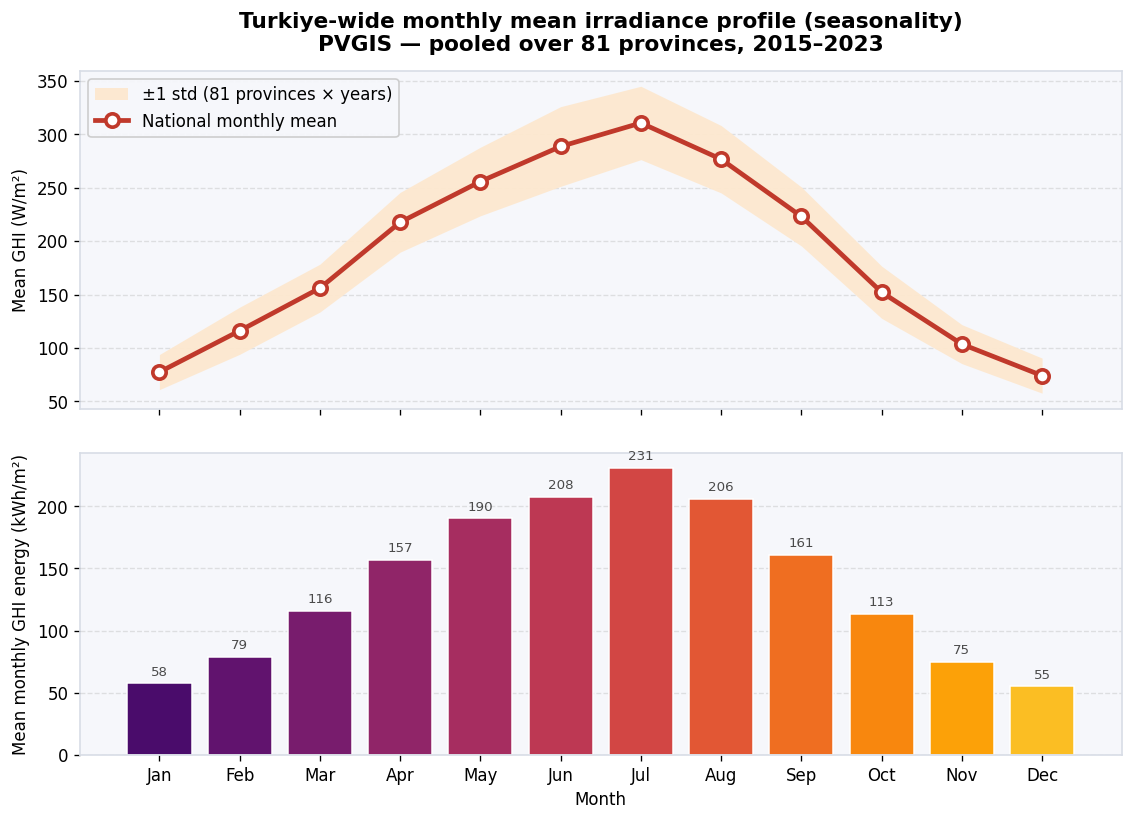

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    dm = df_monthly.copy()
except NameError:
    cwd = Path.cwd().resolve()
    root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "processed").exists()),
        None,
    )
    if root is None:
        raise RuntimeError(
            "df_monthly missing and project root not found. Run upstream cells or open notebook from repo."
        )
    fp = root / "data" / "processed" / "pvgis_turkey_81_provinces_monthly_2015_2023.csv"
    dm = pd.read_csv(fp, parse_dates=["date"])

prof = (
    dm.groupby("month", sort=True)
    .agg(
        mean_ghi=("avg_ghi_w_m2", "mean"),
        std_ghi=("avg_ghi_w_m2", "std"),
        mean_kwh=("monthly_ghi_kwh_m2", "mean"),
    )
    .reset_index()
)

assert len(prof) == 12

MONTH_ABBR = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
x = np.arange(12)

plt.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#f6f7fb",
        "axes.edgecolor": "#d8dde6",
        "axes.linewidth": 1.0,
        "axes.titleweight": "bold",
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    }
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11.2, 7.4),
    sharex=True,
    dpi=120,
    gridspec_kw={"height_ratios": [1.12, 1.0], "hspace": 0.14},
)

ax0 = axes[0]
m = prof["mean_ghi"].to_numpy()
s = prof["std_ghi"].to_numpy()
ax0.fill_between(
    x,
    m - s,
    m + s,
    color="#fde8cf",
    linewidth=0,
    alpha=0.95,
    label="±1 std (81 provinces × years)",
)
ax0.plot(
    x,
    m,
    color="#c0392b",
    lw=2.85,
    marker="o",
    ms=8,
    mfc="white",
    mew=2.2,
    zorder=4,
    label="National monthly mean",
)
ax0.set_ylabel("Mean GHI (W/m²)")
ax0.set_title(
    "Turkiye-wide monthly mean irradiance profile (seasonality)\n"
    "PVGIS — pooled over 81 provinces, 2015–2023",
    fontsize=13,
    pad=12,
)
ax0.legend(loc="upper left", framealpha=0.96)
ax0.grid(True, axis="y")
ax0.set_axisbelow(True)

ax1 = axes[1]
colors = plt.cm.inferno(np.linspace(0.22, 0.85, 12))
bars = ax1.bar(x, prof["mean_kwh"], color=colors, edgecolor="white", linewidth=0.9)
ax1.set_ylabel("Mean monthly GHI energy (kWh/m²)")
ax1.set_xlabel("Month")
ax1.grid(True, axis="y")
ax1.set_axisbelow(True)

for rect, h in zip(bars, prof["mean_kwh"]):
    ax1.annotate(
        f"{h:.0f}",
        xy=(rect.get_x() + rect.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#4a4a4a",
    )

ax1.set_xticks(x)
ax1.set_xticklabels(MONTH_ABBR)

fig.align_ylabels(axes)
plt.tight_layout()
plt.show()

### Insights from the chart (seasonality)

> **Takeaway:** PVGIS monthly data here is a *pooled* average across 81 provinces and 2015–2023. That yields a single "national" profile; investment decisions still require drilling down to **province / site** level.

---

#### Power (top) vs energy (bottom) are not the same thing

- **Mean GHI (W/m²)** reflects roughly *instantaneous irradiance / power density*; **kWh/m²** is *integrated energy over the month* (scaled by hours in that month).
- The two panels therefore do not duplicate each other; together they clarify both **peak-season intensity** and **winter short-day effects**.

#### Strong seasonal amplitude

- In the top panel, the national mean profile sits near **~75 W/m²** in winter months and peaks above **~300 W/m²** in mid-summer — roughly a **four-fold** swing in *power density* across the year.
- In the bottom panel, comparing the **highest** typical monthly energy (on the order of **~231 kWh/m²**) with the **lowest** (**~55 kWh/m²**) shows an **~4×** "best month vs weakest month" gap on the energy side too. That underscores **material intra-year variation in capacity factor** (relevant for cash flow and financing stress tests).

#### Asymmetric ramps: spring accelerates, autumn falls fast

- From roughly February–May the curve tends to **rise steeply**; from August–November it tends to **fall steeply**.
- In operational terms, this supports a pattern where the **summer window is relatively short but intense**, while winter is **longer but low-output**.

#### The ±1σ band widens in summer

- The shaded band shows spread of GHI around the national mean across **province × year** draws. **Thicker bands in summer** suggest geographic disagreement is more pronounced when irradiance is high (south vs coast vs inland vs elevation, etc.).
- **Investment lesson:** The national mean is a useful *summary*; for **single-location** decisions that dispersion can either inflate **wrong-site** risk or hide **high-potential** pockets.

#### June–August: the high-energy core of the year

- Bar heights show the **summer trio** carries a large share of annual energy. That raises practical themes such as:
  - **Seasonally concentrated cash generation**
  - **Maintenance / outage planning** being critical in summer months
  - Potentially **storage or commercial structuring** where relevant

---

*Closing note:* This figure illustrates **national-average seasonality**; the next step in feasibility or modelling is to **disaggregate** by your target province or site (and validate with PVGIS or on-site data where appropriate).


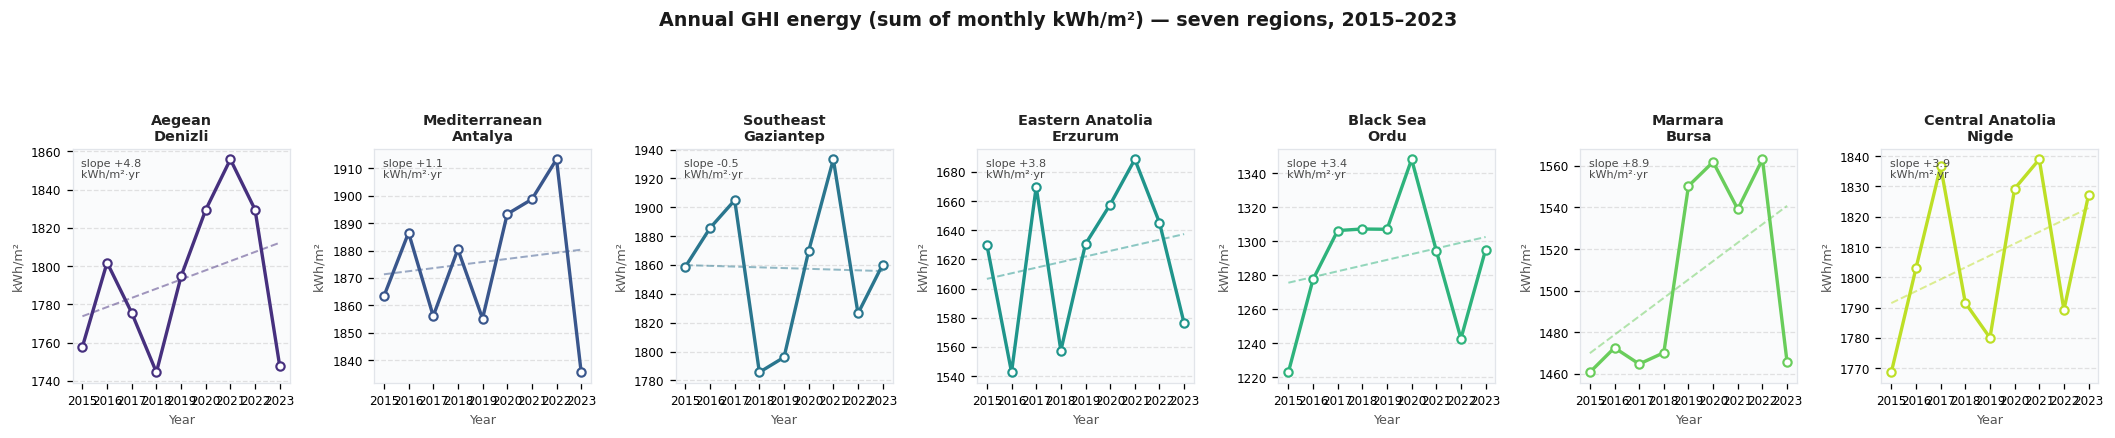

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    dfa = df_annual.copy()
except NameError:
    cwd = Path.cwd().resolve()
    root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "processed").exists()),
        None,
    )
    if root is None:
        raise RuntimeError("df_annual missing and project root not found.")
    dfa = pd.read_csv(
        root / "data" / "processed" / "pvgis_turkey_81_provinces_annual_2015_2023.csv"
    )

dfa = dfa.copy()
dfa["year"] = pd.to_numeric(dfa["year"], errors="coerce").astype(int)

PANELS = [
    ("Aegean", "Denizli"),
    ("Mediterranean", "Antalya"),
    ("Southeast", "Gaziantep"),
    ("Eastern Anatolia", "Erzurum"),
    ("Black Sea", "Ordu"),
    ("Marmara", "Bursa"),
    ("Central Anatolia", "Nigde"),
]

y_col = "sum_monthly_ghi_kwh_m2"

plt.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#fafbfc",
        "axes.edgecolor": "#e2e5ea",
        "axes.linewidth": 0.8,
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    }
)

fig, axes = plt.subplots(1, 7, figsize=(18.5, 3.55), dpi=115, sharey=False)
palette = plt.cm.viridis(np.linspace(0.14, 0.9, len(PANELS)))

for ax, (region, city), color in zip(axes, PANELS, palette):
    sub = dfa.loc[dfa["province"] == city].sort_values("year")
    if sub.empty:
        ax.text(
            0.5,
            0.5,
            f"No rows: {city}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=9,
        )
        ax.set_axis_off()
        continue

    x = sub["year"].to_numpy(dtype=float)
    y = sub[y_col].to_numpy(dtype=float)
    ax.plot(
        x,
        y,
        "o-",
        color=color,
        lw=2.1,
        ms=5.2,
        mfc="white",
        mew=1.35,
        zorder=3,
    )

    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 40)
        ax.plot(xs, slope * xs + intercept, "--", color=color, alpha=0.5, lw=1.25, zorder=2)
        ax.text(
            0.04,
            0.96,
            f"slope {slope:+.1f}\nkWh/m²·yr",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=7,
            color="#4a4a4a",
            linespacing=1.15,
        )

    ax.set_title(f"{region}\n{city}", fontsize=9, pad=5, color="#222", fontweight="600")
    ax.set_xlabel("Year", fontsize=8, color="#555")
    ax.set_ylabel("kWh/m²", fontsize=8, color="#555")
    ax.tick_params(axis="both", labelsize=7.5)
    ax.set_xticks(x.astype(int))
    ax.grid(True, axis="y")
    ax.set_axisbelow(True)

fig.suptitle(
    "Annual GHI energy (sum of monthly kWh/m²) — seven regions, 2015–2023",
    fontsize=12,
    fontweight="bold",
    y=1.06,
    color="#1a1a1a",
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Insights from the seven-province annual trend (2015–2023)

> **Takeaway:** Nine yearly points per city is enough to *see* year-to-year noise and a simple OLS slope — not enough to claim climate trends or project the 2030s. Treat slopes as **descriptive** labels on this PVGIS-backed slice.

---

#### Most panels slope up; one is flat-to-down
- **Six of seven** provinces show a **positive** linear slope in annual summed monthly GHI energy (kWh/m²).
- **Gaziantep (Southeast)** is the exception with a **slightly negative** slope despite very high absolute levels — high mean irradiance does not guarantee a rising *inter-annual* line on a short window.

#### 2023 looks like a shared “step down” for several cities
- After relatively strong 2021–2022 values, **2023 drops** are visible in several panels (e.g. Denizli, Antalya, Erzurum, Bursa). That pattern can reflect **meteorological variability**, **API/data vintage effects**, or **calendar/hour coverage** differences across years — not automatically a structural break.

#### Geography still dominates the vertical scale
- **Mediterranean / Southeast** cities sit at the **top** of the kWh/m² range (often near ~1.9k kWh/m² class peaks in this sample).
- **Black Sea (Ordu)** sits **lowest** on the axis — expected given latitude and cloud climatology — yet still posts a **positive** slope here, meaning “low but not flat” inter-annual movement.

#### Bursa shows the steepest positive slope in this set
- **Marmara (Bursa)** has the **largest positive slope** among the seven, but also a sharp **2023 pullback** after a local high — the line is informative, but **do not over-fit** a story to nine points.

#### How to use this figure in a workflow
- Use it for **comparative storytelling** across representative regions and for **sanity-checking** year-to-year stability before province-level modelling.
- Next step remains **site-specific** PVGIS or measured series, plus longer windows if you need **trend attribution** rather than a compact EDA view.

---

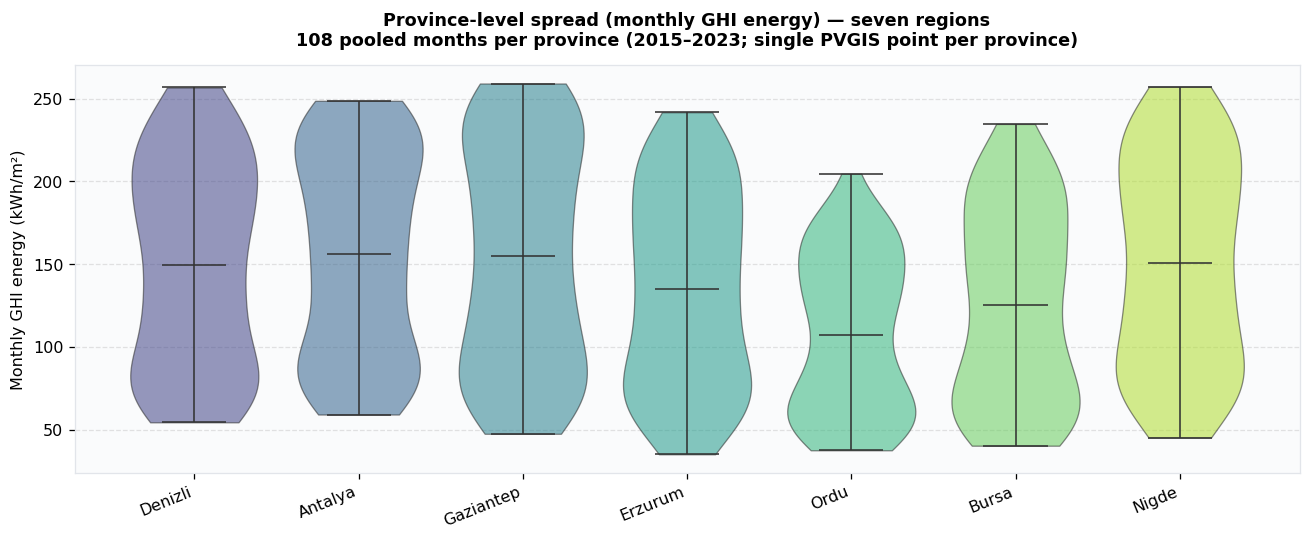

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    dm = df_monthly.copy()
except NameError:
    cwd = Path.cwd().resolve()
    root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "processed").exists()),
        None,
    )
    if root is None:
        raise RuntimeError("df_monthly missing and project root not found.")
    dm = pd.read_csv(
        root / "data" / "processed" / "pvgis_turkey_81_provinces_monthly_2015_2023.csv",
        parse_dates=["date"],
    )

PROVINCES = [
    "Denizli",
    "Antalya",
    "Gaziantep",
    "Erzurum",
    "Ordu",
    "Bursa",
    "Nigde",
]
metric = "monthly_ghi_kwh_m2"

sub = dm.loc[dm["province"].isin(PROVINCES), ["province", metric]].dropna()
series_list = [sub.loc[sub["province"] == p, metric].to_numpy() for p in PROVINCES]

plt.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#fafbfc",
        "axes.edgecolor": "#e2e5ea",
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    }
)

fig, ax = plt.subplots(figsize=(11.5, 4.8), dpi=115)
positions = np.arange(1, len(PROVINCES) + 1)
parts = ax.violinplot(
    series_list,
    positions=positions,
    widths=0.78,
    showmeans=True,
    showmedians=False,
    showextrema=True,
)

colors = plt.cm.viridis(np.linspace(0.2, 0.88, len(PROVINCES)))
for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.55)
    body.set_edgecolor("#2b2b2b")
    body.set_linewidth(0.8)

for key in ("cbars", "cmins", "cmaxes", "cmeans"):
    if key in parts:
        parts[key].set_color("#333333")
        parts[key].set_linewidth(1.0)

ax.set_xticks(positions)
ax.set_xticklabels(PROVINCES, rotation=22, ha="right")
ax.set_ylabel("Monthly GHI energy (kWh/m²)")
ax.set_title(
    "Province-level spread (monthly GHI energy) — seven regions\n"
    "108 pooled months per province (2015–2023; single PVGIS point per province)",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax.grid(True, axis="y")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Insights from the violin (seven-province monthly spread)

> **Takeaway:** Each violin pools **108 months** (9 years × 12) from one PVGIS representative point per province. The shape summarizes **within-year variability** of monthly GHI energy (kWh/m²); it is not a substitute for site-level micro-climate work.

---

#### Large vertical span everywhere — seasonality dominates the scale

- Every province shows a **wide** monthly range from low winter-like months to high summer months.
- That implies **strong intra-year swings** in implied production / capacity factor, even before inverter clipping or O&M derates.

#### Level ordering matches broad geography

- **Gaziantep, Antalya, Niğde, Denizli** sit **higher** in typical monthly energy (denser mass and medians toward the upper half of the chart).
- **Ordu** is clearly **lower** in both typical level and upper tail — consistent with **Black Sea** cloudiness and latitude.
- **Bursa** sits **between** Ordu and the southern cluster — plausible for **Marmara** mixing of latitude, weather, and shorter summer peaks than the Mediterranean interior.

#### Median bar vs tails — how to read the silhouette

- The **horizontal mean marker** (matplotlib default) tracks the arithmetic mean of the 108 monthly values; the **violin width** is **kernel density**, not a confidence interval.
- **Wide “belly”** near mid-range values means many months land in that band (often **shoulder seasons**).
- **Thin neck + long upper tail** points to a smaller set of **very strong summer months** pulling the high end.

#### Pair with the annual line chart

- **Annual line + slope:** inter-annual drift / noise in **year totals**.
- **Violin:** distribution of **monthly** energy around each province’s long-run seasonal pattern.
- Together they separate “**how seasonal**” from “**which years were stronger**” on this PVGIS slice.

---

*Caution:* One coordinate per province is useful for **comparative EDA**; investment screening should still move to **project coordinates**, terrain/horizon, and measured or higher-resolution data where decisions are material.

In [1]:
from pathlib import Path

import pandas as pd

try:
    dfa = df_annual.copy()
except NameError:
    cwd = Path.cwd().resolve()
    root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "processed").exists()),
        None,
    )
    if root is None:
        raise RuntimeError("df_annual missing and project root not found.")
    dfa = pd.read_csv(
        root / "data" / "processed" / "pvgis_turkey_81_provinces_annual_2015_2023.csv"
    )

TOP_N = 10
BOTTOM_N = 10
YEARS = (2015, 2023)

rank = (
    dfa.groupby(["plate_code", "province"], as_index=False)
    .agg(
        mean_annual_kwh_m2=("sum_monthly_ghi_kwh_m2", "mean"),
        years_observed=("year", "nunique"),
    )
    .sort_values("mean_annual_kwh_m2", ascending=False)
    .reset_index(drop=True)
)
rank["rank"] = rank.index + 1
rank["mean_annual_kwh_m2"] = rank["mean_annual_kwh_m2"].round(1)

top = rank.head(TOP_N)[
    ["rank", "plate_code", "province", "mean_annual_kwh_m2", "years_observed"]
].copy()
bottom = (
    rank.tail(BOTTOM_N)
    .iloc[::-1]
    .assign(rank=lambda d: d["rank"].astype(int))
    [["rank", "plate_code", "province", "mean_annual_kwh_m2", "years_observed"]]
)

print(
    f"Province solar potential ranking — mean annual GHI energy (kWh/m²), "
    f"{YEARS[0]}–{YEARS[1]} (PVGIS, one point per province)\n"
)
print(f"=== Top {TOP_N} (highest potential) ===")
display(top)
print(f"\n=== Bottom {BOTTOM_N} (lowest potential) ===")
display(bottom)

summary = pd.DataFrame(
    {
        "metric": ["n_provinces", "national_mean_kwh_m2", "top10_mean_kwh_m2", "bottom10_mean_kwh_m2"],
        "value": [
            len(rank),
            round(rank["mean_annual_kwh_m2"].mean(), 1),
            round(top["mean_annual_kwh_m2"].mean(), 1),
            round(bottom["mean_annual_kwh_m2"].mean(), 1),
        ],
    }
)
print("\n=== Summary ===")
display(summary)

Province solar potential ranking — mean annual GHI energy (kWh/m²), 2015–2023 (PVGIS, one point per province)

=== Top 10 (highest potential) ===


,rank,plate_code,province,mean_annual_kwh_m2,years_observed
0,1,79,Kilis,1888.8,9
1,2,63,Sanliurfa,1888.7,9
2,3,7,Antalya,1875.8,9
3,4,31,Hatay,1861.0,9
4,5,27,Gaziantep,1857.9,9
5,6,9,Aydin,1857.7,9
6,7,47,Mardin,1856.2,9
7,8,2,Adiyaman,1854.8,9
8,9,46,Kahramanmaras,1852.0,9
9,10,70,Karaman,1840.5,9



=== Bottom 10 (lowest potential) ===


,rank,plate_code,province,mean_annual_kwh_m2,years_observed
80,81,61,Trabzon,1050.2,9
79,80,53,Rize,1161.2,9
78,79,28,Giresun,1191.7,9
77,78,52,Ordu,1289.1,9
76,77,55,Samsun,1385.0,9
75,76,81,Duzce,1405.5,9
74,75,8,Artvin,1432.5,9
73,74,57,Sinop,1434.7,9
72,73,67,Zonguldak,1437.1,9
71,72,54,Sakarya,1442.7,9



=== Summary ===


,metric,value
0,n_provinces,81.0
1,national_mean_kwh_m2,1647.9
2,top10_mean_kwh_m2,1863.3
3,bottom10_mean_kwh_m2,1323.0


### Insights from province ranking (top / bottom lists)

> **Takeaway:** Across **81 provinces**, mean annual GHI energy (2015–2023) averages **~1,648 kWh/m²** nationally. The **top 10** cluster near **~1,863 kWh/m²**; the **bottom 10** near **~1,323 kWh/m²** — a **~540 kWh/m²** gap between those cohort means (~**41%** relative spread). Use this as a **pre-feasibility shortlist**, not a site-level verdict.

---

#### Headline numbers from this run

| Cohort | Mean annual GHI energy (kWh/m²) |
|--------|----------------------------------|
| All 81 provinces | **1,647.9** |
| Top 10 | **1,863.3** |
| Bottom 10 | **1,323.0** |

- **#1 Kilis (1,888.8)** and **#2 Sanliurfa (1,888.7)** are essentially tied at the top.
- **#81 Trabzon (1,050.2)** is the clear floor — about **~839 kWh/m²** below Kilis on this metric (~**80%** of Kilis’s level).

#### Top 10 — where to prioritize screening

1. **Kilis** — 1,888.8  
2. **Sanliurfa** — 1,888.7  
3. **Antalya** — 1,875.8  
4. **Hatay** — 1,861.0  
5. **Gaziantep** — 1,857.9  
6. **Aydin** — 1,857.7  
7. **Mardin** — 1,856.2  
8. **Adiyaman** — 1,854.8  
9. **Kahramanmaras** — 1,852.0  
10. **Karaman** — 1,840.5  

**Pattern:** Southeast, Mediterranean, and upper southern Anatolia dominate — consistent with **high sun exposure** and lower-latitude / inland dry-climate provinces in this PVGIS slice.

#### Bottom 10 — early deprioritization candidates

72. **Sakarya** — 1,442.7  
73. **Zonguldak** — 1,437.1  
74. **Sinop** — 1,434.7  
75. **Artvin** — 1,432.5  
76. **Duzce** — 1,406.5  
77. **Samsun** — 1,385.0  
78. **Ordu** — 1,289.1  
79. **Giresun** — 1,191.7  
80. **Rize** — 1,161.2  
81. **Trabzon** — 1,050.2  

**Pattern:** **Black Sea** and **northern Marmara** provinces fill the tail — cloudiness and latitude show up as materially lower annual energy on the same basis.

#### Investment workflow

- **Top list:** fast-track for detailed **coordinate-level** PVGIS, land/grid checks, and yield/LCOE models.
- **Bottom list:** only proceed if **tariff, PPA, or site micro-climate** compensates; do not assume provincial centroid equals your parcel.
- Provinces in the **middle of the national distribution** (~1,500–1,700 kWh/m²) may still win on **grid, capex, or policy** — rank is **resource-only**.

#### Limits

- **One PVGIS point per province**; all rows use **9 years** of monthly data in this extract.
- Metric is **irradiation proxy**, not bankable production (no DC/AC losses, soiling, or curtailment).
- Next step: align shortlists with **MAPE-backed** forecasts and project-specific coordinates before commitment.
